# 4.3 — Boosting moderne avec gestion native

Cette famille regroupe les bibliothèques de gradient boosting **modernes** qui implémentent leur propre gestion des valeurs manquantes et des variables catégorielles. C'est la **réponse « plus ingénieuse »** à la directive du prof (« si on fait du OneHotEncoder, le résultat sera mauvais ») :

- pas d'imputation en amont → le modèle apprend si NaN est un signal en soi (NaN-aware splits) ;
- pas de OneHotEncoding → pas d'explosion de dimension (le `preprocessor_encoded` produit ~130 colonnes, ici on reste sur les colonnes d'origine) ;
- splits catégoriels intelligents (XGBoost ≥ 1.6 avec `enable_categorical=True`, LightGBM nativement, CatBoost via *target statistics*).

| Modèle      | Spécificité                                                                                              |
|-------------|----------------------------------------------------------------------------------------------------------|
| XGBoost     | Tree boosting standard, `enable_categorical=True` + `tree_method='hist'` pour activer la gestion native  |
| LightGBM    | Croissance **leaf-wise** (best-first) — plus rapide et expressive, NaN et `pd.Categorical` gérés nativement |
| CatBoost    | **Ordered boosting** + arbres symétriques — robuste sur petits jeux ; comble les NaN catégoriels (`CatBoostPrep`) |

**Bonus pédagogique** : on entraîne deux fois XGBoost — avec `preprocessor_native` et avec `preprocessor_encoded` (OneHot) — pour quantifier le gain de la gestion native (réponse explicite à la consigne du prof).

In [1]:
%load_ext autoreload
%autoreload 2
%run 2_data_prep.ipynb

Dimensions brutes : (1460, 81)
Nombre de points supprimés : 2
Dimensions après suppression : (1458, 81)
Variables après ingénierie : 90 colonnes (+8 dérivées)
Corrélation des variables dérivées avec SalePrice_log :
  TotalSF            : +0.825
  TotalBathrooms     : +0.677
  HouseAge           : -0.588
  YearsSinceRemodel  : -0.569
  GarageAge          : -0.543
  HasGarage          : +0.323
  HasSecondFloor     : +0.151
  HasPool            : +0.077   <-- faible (|r| < 0.1)
X_train : (1166, 83)   |   X_test : (292, 83)
Colonnes retirées (colinéarité) : ['GarageArea', 'TotalBsmtSF', 'TotRmsAbvGrd', 'GarageYrBlt']
NaN dans X_train : 6276 cellules sur 96778
Audit de cardinalité des colonnes nominales (sur X_train) :
Colonne           modalités   bucket
  Neighborhood           25     TargetEncoder (haute)  [imput. mode]
  Exterior2nd            16     TargetEncoder (haute)  [imput. mode]
  Exterior1st            15     TargetEncoder (haute)  [imput. mode]
  MSSubClass             15     

In [2]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# CatBoostRegressorCV (+ CatBoostPrep) sont définis dans 2_data_prep et importés via %run.

FAMILY = 'native_boosting'

## 4.3.1 XGBoost — gestion native

### Hypothèses du modèle
- Boosting de gradient sur arbres : chaque arbre apprend les pseudo-résidus du modèle courant (idem GradientBoosting sklearn).
- **Différence clé** : XGBoost gère les valeurs manquantes en apprenant la **direction de défaut** (NaN-aware splits) — la donnée manquante devient un signal apprenable.
- Avec `enable_categorical=True` + `tree_method='hist'`, XGBoost fait aussi des splits sur les `pd.Categorical` directement (algorithme spécifique pour partitionner les niveaux catégoriels).

XGBoost native — CV RMSLE: 0.1256   Holdout RMSLE: 0.1210   fit_time: 0.76s


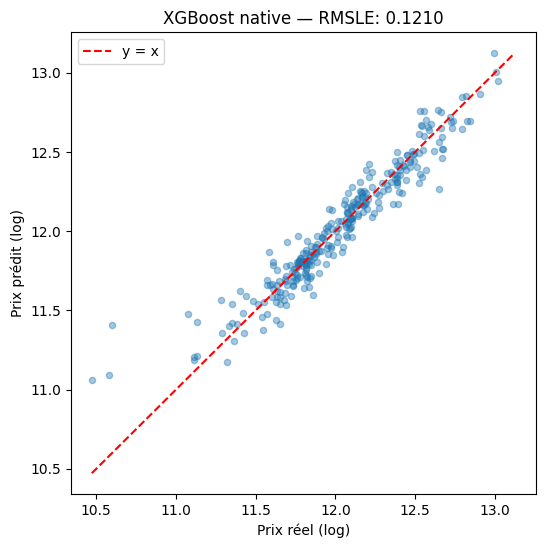

PosixPath('results/family_native_boosting.json')

In [3]:
t0 = time.time()
xgb_native_pipe = Pipeline([
    ('preprocessor', preprocessor_native),
    ('model', XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        enable_categorical=True, tree_method='hist',
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )),
])
xgb_native_pipe.fit(X_train, y_train_log)
xgb_native_fit_s = time.time() - t0

xgb_native_pred = xgb_native_pipe.predict(X_test)
xgb_native_holdout = rmsle_score(y_test_log, xgb_native_pred)
xgb_native_cv = cv_rmsle(xgb_native_pipe, X_train, y_train_log)

print(f"XGBoost native — CV RMSLE: {xgb_native_cv:.4f}   Holdout RMSLE: {xgb_native_holdout:.4f}   fit_time: {xgb_native_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, xgb_native_pred, title=f"XGBoost native — RMSLE: {xgb_native_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'XGBoost_native', cv_rmsle=xgb_native_cv, holdout_rmsle=xgb_native_holdout, fit_time_s=xgb_native_fit_s,
               params={'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 4, 'enable_categorical': True})

## 4.3.2 XGBoost — variante OneHot (pour comparaison)

On entraîne le **même** XGBoost (mêmes hyperparamètres) sur le préprocesseur OneHot. La différence de RMSLE et de temps d'entraînement isolent l'apport pédagogique de la gestion native — la réponse concrète à la directive du prof.

In [4]:
t0 = time.time()
xgb_enc_pipe = Pipeline([
    ('preprocessor', preprocessor_encoded),
    ('model', XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )),
])
xgb_enc_pipe.fit(X_train, y_train_log)
xgb_enc_fit_s = time.time() - t0

xgb_enc_pred = xgb_enc_pipe.predict(X_test)
xgb_enc_holdout = rmsle_score(y_test_log, xgb_enc_pred)
xgb_enc_cv = cv_rmsle(xgb_enc_pipe, X_train, y_train_log)

print(f"XGBoost OneHot — CV RMSLE: {xgb_enc_cv:.4f}   Holdout RMSLE: {xgb_enc_holdout:.4f}   fit_time: {xgb_enc_fit_s:.2f}s")
print()
print(f"Comparaison native vs OneHot (mêmes hyperparams) :")
print(f"  CV RMSLE      : native {xgb_native_cv:.4f}   |  OneHot {xgb_enc_cv:.4f}   |  delta {xgb_enc_cv - xgb_native_cv:+.4f}")
print(f"  Holdout RMSLE : native {xgb_native_holdout:.4f}   |  OneHot {xgb_enc_holdout:.4f}   |  delta {xgb_enc_holdout - xgb_native_holdout:+.4f}")
print(f"  fit_time      : native {xgb_native_fit_s:.2f}s   |  OneHot {xgb_enc_fit_s:.2f}s")

publish_result(FAMILY, 'XGBoost_onehot', cv_rmsle=xgb_enc_cv, holdout_rmsle=xgb_enc_holdout, fit_time_s=xgb_enc_fit_s,
               params={'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 4, 'enable_categorical': False},
               notes='Variante pédagogique pour comparaison avec XGBoost_native')

XGBoost OneHot — CV RMSLE: 0.1237   Holdout RMSLE: 0.1178   fit_time: 0.63s

Comparaison native vs OneHot (mêmes hyperparams) :
  CV RMSLE      : native 0.1256   |  OneHot 0.1237   |  delta -0.0018
  Holdout RMSLE : native 0.1210   |  OneHot 0.1178   |  delta -0.0032
  fit_time      : native 0.76s   |  OneHot 0.63s


PosixPath('results/family_native_boosting.json')

## 4.3.3 XGBoost — optimisation Optuna

On optimise les hyperparamètres du XGBoost natif avec Optuna sur 30 trials (TPE sampler, 5-fold CV interne). Les 4 graphiques du cours (`optimization_history`, `param_importances`, `contour`, `slice`) sont produits ci-dessous.

In [5]:
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 800),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }
    pipe = Pipeline([
        ('preprocessor', preprocessor_native),
        ('model', XGBRegressor(**params, enable_categorical=True, tree_method='hist',
                               random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)),
    ])
    rmsle = -cross_val_score(pipe, X_train, y_train_log, cv=5,
                             scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    return rmsle

t0 = time.time()
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(xgb_objective, n_trials=30, show_progress_bar=False)
study_fit_s = time.time() - t0

print(f"Optuna terminé en {study_fit_s:.1f}s — meilleur CV RMSLE: {study.best_value:.4f}")
print(f"Meilleurs hyperparamètres :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Optuna terminé en 39.9s — meilleur CV RMSLE: 0.1171
Meilleurs hyperparamètres :
  n_estimators: 437
  learning_rate: 0.023662268168248044
  max_depth: 4
  min_child_weight: 3
  subsample: 0.6017047711621712
  colsample_bytree: 0.7049428578499447
  reg_alpha: 0.0019384197835461844
  reg_lambda: 0.000125191594999711


### Visualisations Optuna (exigence du cours 09_Hyperparameter_Tuning)

Quatre graphiques standard : historique, importance des hyperparamètres, contour 2D et slice.

/tmp/claude-1000/ipykernel_142158/3720455269.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


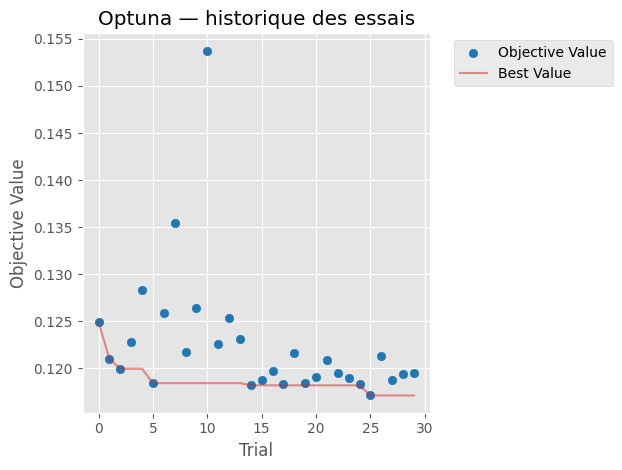

/tmp/claude-1000/ipykernel_142158/3720455269.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


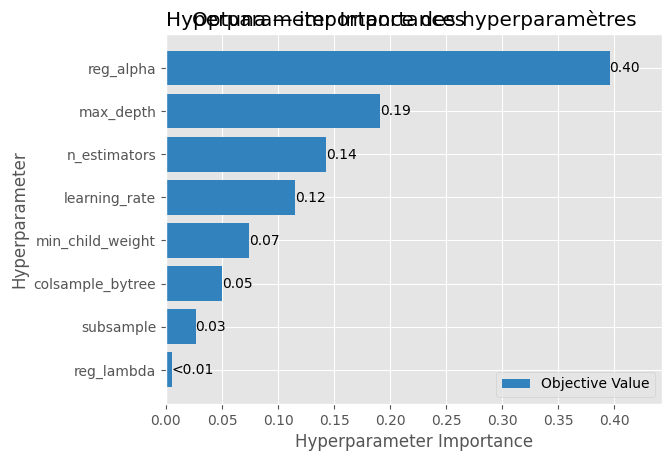

/tmp/claude-1000/ipykernel_142158/3720455269.py:10: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_contour(study, params=['learning_rate', 'max_depth'])


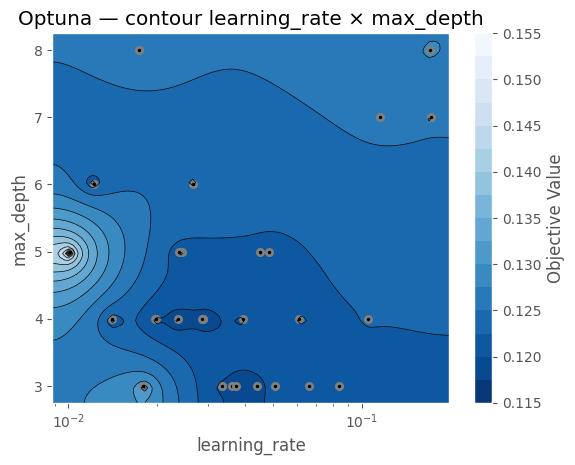

/tmp/claude-1000/ipykernel_142158/3720455269.py:17: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_slice(study, params=['learning_rate', 'max_depth', 'n_estimators'])


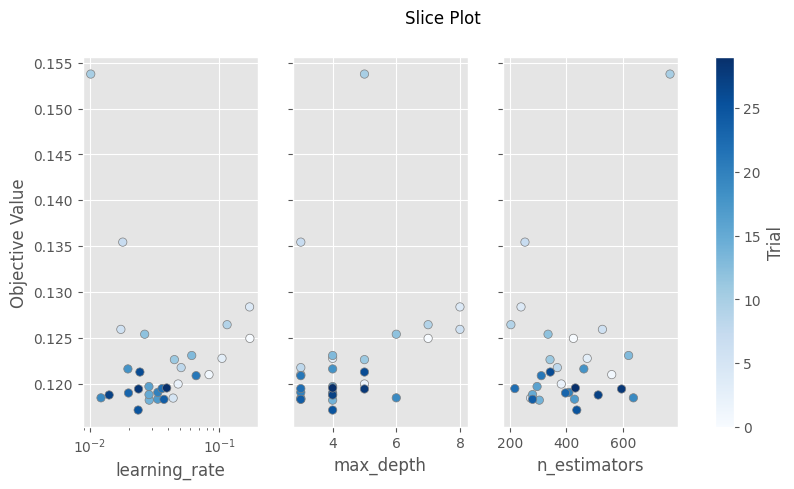

In [6]:
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna — historique des essais")
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Optuna — importance des hyperparamètres")
plt.show()

try:
    optuna.visualization.matplotlib.plot_contour(study, params=['learning_rate', 'max_depth'])
    plt.title("Optuna — contour learning_rate × max_depth")
    plt.show()
except Exception as e:
    print(f"plot_contour skipped: {e}")

try:
    optuna.visualization.matplotlib.plot_slice(study, params=['learning_rate', 'max_depth', 'n_estimators'])
    plt.show()
except Exception as e:
    print(f"plot_slice skipped: {e}")

XGBoost (tuned) — CV RMSLE: 0.1171   Holdout RMSLE: 0.1193   fit_time (final): 0.61s   optuna: 39.9s


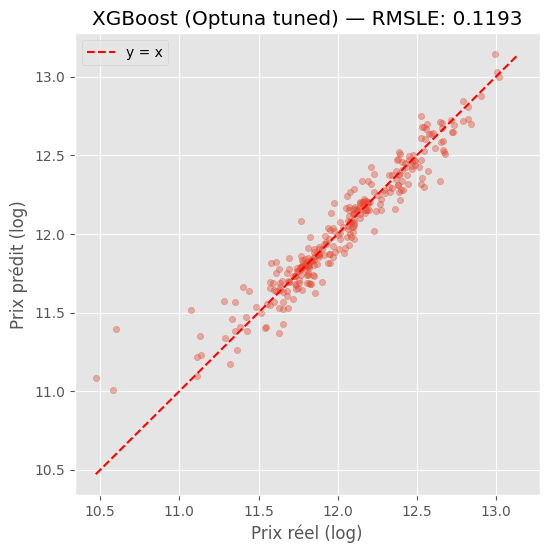

PosixPath('results/family_native_boosting.json')

In [7]:
t0 = time.time()
xgb_tuned_pipe = Pipeline([
    ('preprocessor', preprocessor_native),
    ('model', XGBRegressor(**study.best_params, enable_categorical=True, tree_method='hist',
                           random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)),
])
xgb_tuned_pipe.fit(X_train, y_train_log)
xgb_tuned_fit_s = time.time() - t0

xgb_tuned_pred = xgb_tuned_pipe.predict(X_test)
xgb_tuned_holdout = rmsle_score(y_test_log, xgb_tuned_pred)
xgb_tuned_cv = float(study.best_value)

print(f"XGBoost (tuned) — CV RMSLE: {xgb_tuned_cv:.4f}   Holdout RMSLE: {xgb_tuned_holdout:.4f}   fit_time (final): {xgb_tuned_fit_s:.2f}s   optuna: {study_fit_s:.1f}s")
predicted_vs_actual_plot(y_test_log, xgb_tuned_pred, title=f"XGBoost (Optuna tuned) — RMSLE: {xgb_tuned_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'XGBoost_tuned', cv_rmsle=xgb_tuned_cv, holdout_rmsle=xgb_tuned_holdout,
               fit_time_s=xgb_tuned_fit_s, params=study.best_params,
               notes=f'Optuna 30 trials over {study_fit_s:.0f}s')

## 4.3.4 LightGBM

### Hypothèses du modèle
- Boosting de gradient sur arbres, comme XGBoost, mais avec une croissance **leaf-wise** (best-first) : à chaque étape, LightGBM divise la feuille qui réduit le plus la perte, au lieu de développer l'arbre niveau par niveau (level-wise). Résultat : arbres plus profonds et asymétriques, apprentissage plus rapide, mais **risque de surapprentissage** accru sur petits jeux → on garde un `num_leaves` modéré (31).
- **Valeurs manquantes** gérées nativement (direction de défaut apprise, comme XGBoost).
- **Catégorielles** : LightGBM détecte automatiquement les colonnes `pd.Categorical` (`categorical_feature='auto'`) et partitionne directement les niveaux ; les `NaN` catégoriels (codes négatifs) sont traités comme une modalité manquante. On consomme donc **`preprocessor_native`** sans adaptation.

LightGBM — CV RMSLE: 0.1274   Holdout RMSLE: 0.1308   fit_time: 3.53s


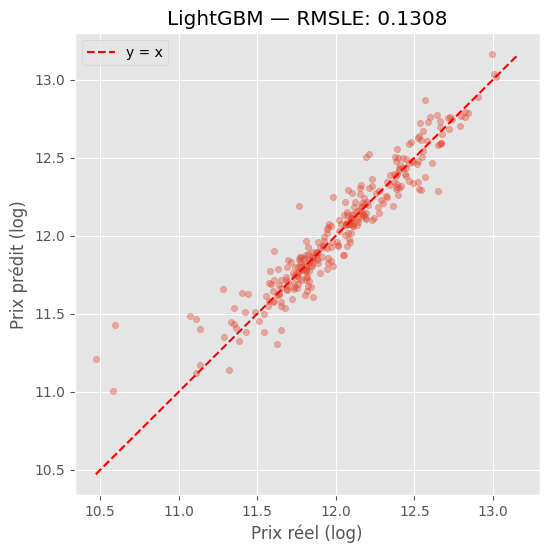

PosixPath('results/family_native_boosting.json')

In [8]:
t0 = time.time()
lgb_pipe = Pipeline([
    ('preprocessor', preprocessor_native),
    ('model', LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    )),
])
lgb_pipe.fit(X_train, y_train_log)
lgb_fit_s = time.time() - t0

lgb_pred = lgb_pipe.predict(X_test)
lgb_holdout = rmsle_score(y_test_log, lgb_pred)
lgb_cv = cv_rmsle(lgb_pipe, X_train, y_train_log)

print(f"LightGBM — CV RMSLE: {lgb_cv:.4f}   Holdout RMSLE: {lgb_holdout:.4f}   fit_time: {lgb_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, lgb_pred, title=f"LightGBM — RMSLE: {lgb_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'LightGBM', cv_rmsle=lgb_cv, holdout_rmsle=lgb_holdout, fit_time_s=lgb_fit_s,
               params={'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31},
               notes='Croissance leaf-wise, pd.Categorical détecté nativement')

## 4.3.5 CatBoost

### Hypothèses du modèle
- Boosting de gradient sur arbres, mais avec deux spécificités majeures :
  - **Ordered boosting** : pour estimer les statistiques de cible des catégorielles, CatBoost n'utilise que les observations *précédentes* dans une permutation aléatoire, ce qui évite le **biais de fuite de cible** qui guette le target encoding classique.
  - **Arbres symétriques (oblivious)** : toutes les feuilles d'un même niveau partagent le même test, ce qui agit comme une régularisation forte — particulièrement utile sur un petit jeu (~1 160 lignes).
- **Catégorielles** gérées nativement via `cat_features` (target statistics ordonnées), sans OneHot.
- **Limite à connaître** : contrairement à XGBoost et LightGBM, CatBoost **ne gère pas les `NaN` catégoriels**. On les comble par une modalité dédiée `'NAN'` via le prétraitement `CatBoostPrep` (défini dans `2_data_prep`) ; les `NaN` numériques, eux, sont gérés nativement.

CatBoost — CV RMSLE: 0.1223   Holdout RMSLE: 0.1175   fit_time: 5.79s


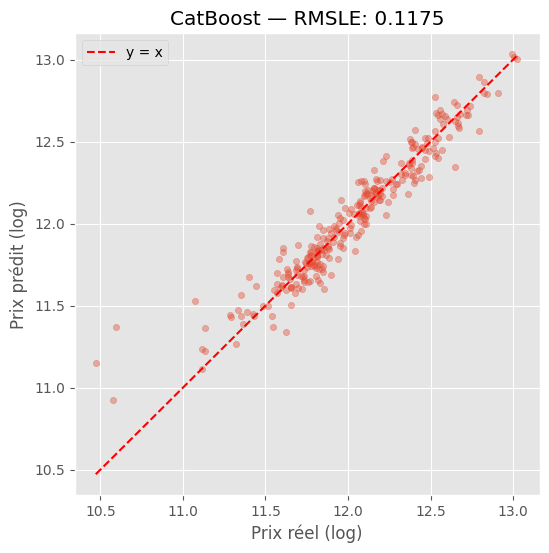

PosixPath('results/family_native_boosting.json')

In [9]:
cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

t0 = time.time()
cb_pipe = Pipeline([
    ('preprocessor', CatBoostPrep()),
    ('model', CatBoostRegressorCV(
        cat_features=cat_cols,
        iterations=500, learning_rate=0.05, depth=6,
        random_seed=RANDOM_STATE,
    )),
])
cb_pipe.fit(X_train, y_train_log)
cb_fit_s = time.time() - t0

cb_pred = cb_pipe.predict(X_test)
cb_holdout = rmsle_score(y_test_log, cb_pred)
cb_cv = cv_rmsle(cb_pipe, X_train, y_train_log)

print(f"CatBoost — CV RMSLE: {cb_cv:.4f}   Holdout RMSLE: {cb_holdout:.4f}   fit_time: {cb_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, cb_pred, title=f"CatBoost — RMSLE: {cb_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'CatBoost', cv_rmsle=cb_cv, holdout_rmsle=cb_holdout, fit_time_s=cb_fit_s,
               params={'iterations': 500, 'learning_rate': 0.05, 'depth': 6},
               notes='Ordered boosting + arbres symétriques, NaN catégoriels comblés par CatBoostPrep')

## 4.3.6 Comparaison intra-famille

Comparaison des cinq variantes de la famille : les trois XGBoost (natif, OneHot, Optuna) et les deux boosters modernes (LightGBM, CatBoost). Le graphique est alimenté automatiquement par `results/family_native_boosting.json`.

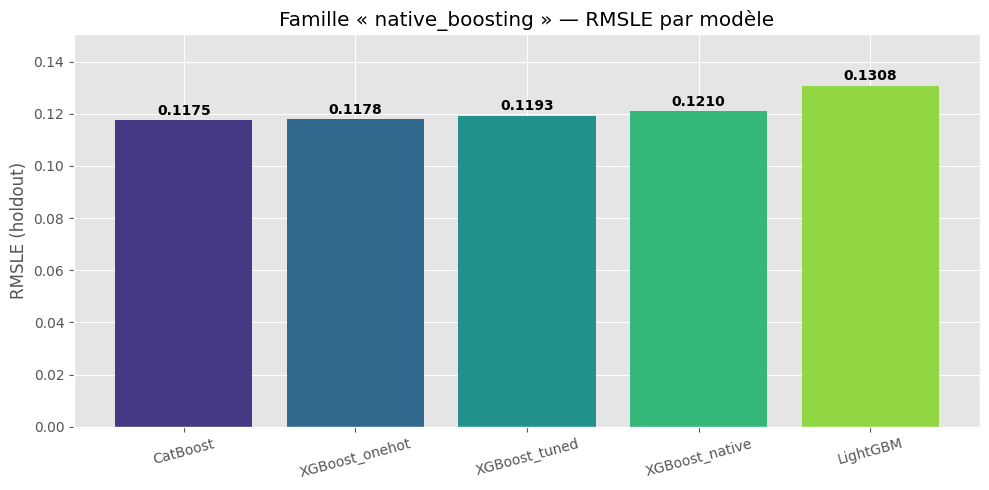

,model,cv_rmsle,holdout_rmsle,fit_time_s,notes
0,CatBoost,0.122280,0.117485,5.785531,"Ordered boosting + arbres symétriques, NaN cat..."
1,XGBoost_onehot,0.123717,0.117796,0.628115,Variante pédagogique pour comparaison avec XGB...
2,XGBoost_tuned,0.117110,0.119286,0.607986,Optuna 30 trials over 40s
3,XGBoost_native,0.125556,0.121032,0.762934,NaN
4,LightGBM,0.127409,0.130811,3.533778,"Croissance leaf-wise, pd.Categorical détecté n..."


In [10]:
family_path = RESULTS_DIR / f'family_{FAMILY}.json'
fam = pd.DataFrame(json.loads(family_path.read_text()))
fam = fam.sort_values('holdout_rmsle').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(fam['model'], fam['holdout_rmsle'], color=sns.color_palette('viridis', len(fam)))
for bar, v in zip(bars, fam['holdout_rmsle']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')
ax.set_ylabel('RMSLE (holdout)')
ax.set_title("Famille « native_boosting » — RMSLE par modèle")
ax.set_ylim(0, fam['holdout_rmsle'].max() * 1.15)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

display(fam[['model', 'cv_rmsle', 'holdout_rmsle', 'fit_time_s', 'notes']])

## 4.3.7 Interprétabilité SHAP du meilleur modèle

Un modèle performant ne suffit pas : chez Inved Corp, il faut pouvoir **justifier** une prédiction à un client ou à un agent immobilier. On utilise pour cela les **valeurs de Shapley** (librairie `shap`), issues de la théorie des jeux : elles décomposent chaque prédiction en la contribution (positive ou négative) de chaque variable.

Le modèle finalement *servi* est le Stacking, mais on interprète ici un **booster performant** (XGBoost tuné, gestion native) comme proxy transparent, pour deux raisons :

- SHAP pour les arbres est **exact et rapide** (contributions calculées directement depuis la structure des arbres), là où un Stacking exigerait une approximation lente.
- La **gestion native** des catégorielles attribue l'importance aux **variables d'origine** (`KitchenQual`, `GrLivArea`, `Neighborhood`…) et non à des fragments OneHot — exactement le « top-3 des facteurs » promis dans le ML Canvas, lisible par un consultant.

On calcule les contributions via le `pred_contribs` natif de XGBoost (compatible `enable_categorical`), puis on les visualise avec `shap`.

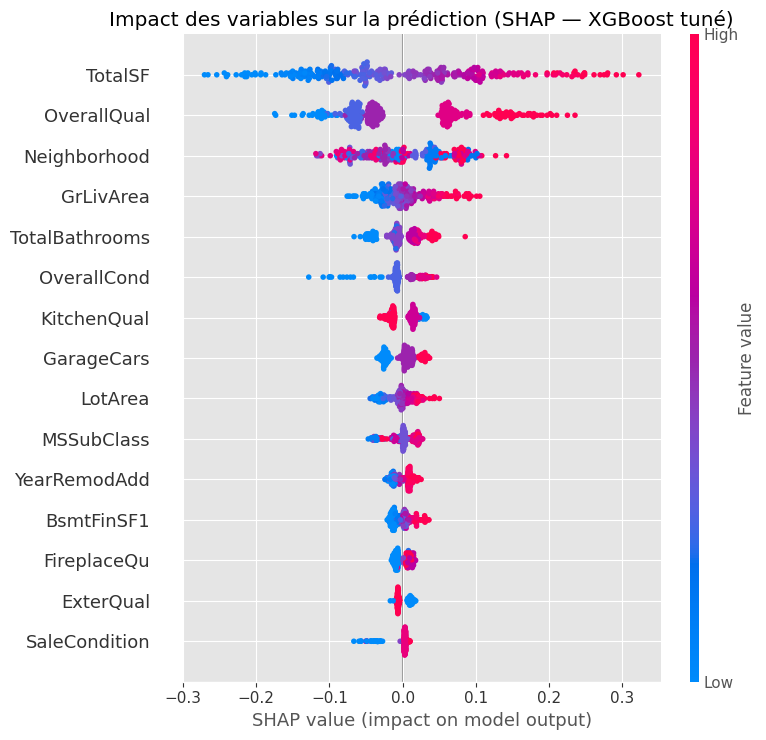

Top-3 facteurs explicatifs (|SHAP| moyen, espace log) :
  1. TotalSF            0.1065
  2. OverallQual        0.0807
  3. Neighborhood       0.0492


In [11]:
import shap
from xgboost import DMatrix

# On réutilise le booster tuné déjà entraîné (gestion native des catégorielles)
booster    = xgb_tuned_pipe.named_steps['model'].get_booster()
prep_nat   = xgb_tuned_pipe.named_steps['preprocessor']
X_te_nat   = prep_nat.transform(X_test)          # DataFrame, colonnes pd.Categorical
feat_names = list(X_te_nat.columns)

# Contributions SHAP via le pred_contribs natif de XGBoost (gère enable_categorical proprement)
dtest    = DMatrix(X_te_nat, enable_categorical=True)
contribs = booster.predict(dtest, pred_contribs=True)   # (n, n_features + 1) ; dernière colonne = biais
shap_values = contribs[:, :-1]
base_values = contribs[:, -1]

# Frame numérique pour la coloration des plots (codes entiers pour les catégorielles)
X_te_num = X_te_nat.copy()
for c in X_te_num.columns:
    if str(X_te_num[c].dtype) == 'category':
        X_te_num[c] = X_te_num[c].cat.codes

# Vue globale : impact de chaque variable sur la prédiction (espace log)
shap.summary_plot(shap_values, X_te_num, feature_names=feat_names, max_display=15, show=False)
plt.title("Impact des variables sur la prédiction (SHAP — XGBoost tuné)")
plt.tight_layout()
plt.show()

# Top-3 des facteurs (|SHAP| moyen) — le « top-3 » du ML Canvas, sur variables d'origine
mean_abs = np.abs(shap_values).mean(axis=0)
imp = pd.Series(mean_abs, index=feat_names).sort_values(ascending=False)
print("Top-3 facteurs explicatifs (|SHAP| moyen, espace log) :")
for rank, (name, val) in enumerate(imp.head(3).items(), start=1):
    print(f"  {rank}. {name:18s} {val:.4f}")

### Explication locale d'une prédiction

Au-delà de la vue globale, SHAP explique **une prédiction individuelle** — c'est le cœur de l'UX promise dans le ML Canvas (« prix prédit + pourquoi »). Le graphique en cascade ci-dessous part de la valeur de base (prix moyen en log) et empile les contributions de chaque variable jusqu'à la prédiction finale pour un bien du jeu de test.

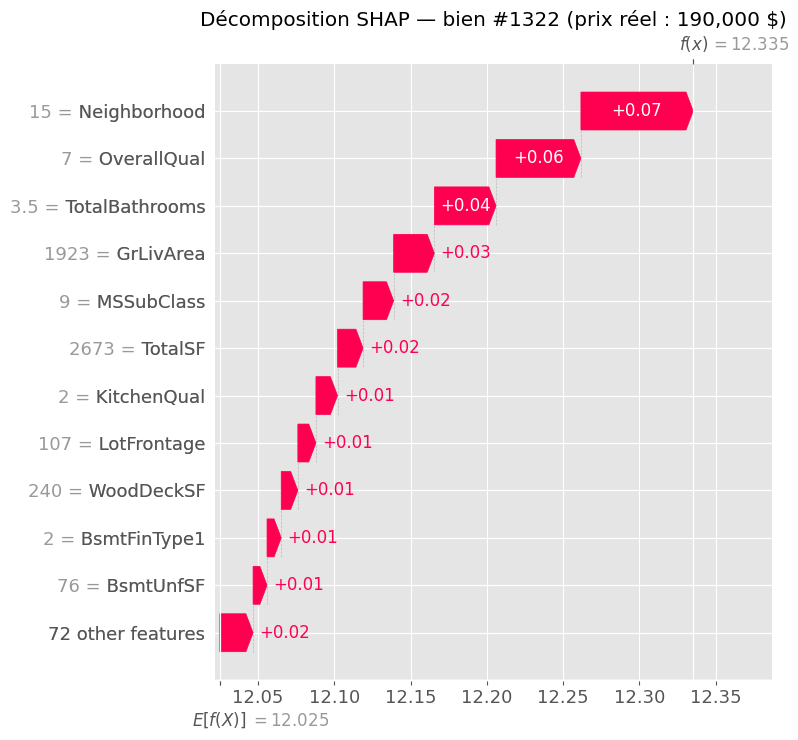

Prix prédit (XGBoost tuné) : 227,602 $
Prix réel                  : 190,000 $


In [12]:
# Explication locale du premier bien du jeu de test
i = 0
expl = shap.Explanation(
    values=shap_values,
    base_values=base_values,
    data=X_te_num.values,
    feature_names=feat_names,
)
shap.plots.waterfall(expl[i], max_display=12, show=False)
plt.title(f"Décomposition SHAP — bien #{X_test.index[i]} "
          f"(prix réel : {np.expm1(y_test_log.iloc[i]):,.0f} $)")
plt.tight_layout()
plt.show()

pred_dollars = np.expm1(xgb_tuned_pred[i])
print(f"Prix prédit (XGBoost tuné) : {pred_dollars:,.0f} $")
print(f"Prix réel                  : {np.expm1(y_test_log.iloc[i]):,.0f} $")

**À retenir.** SHAP rend le modèle *actionnable* pour Inved Corp : (1) le **top-3 des facteurs** alimente directement l'interface consultant (prix + intervalle + 3 leviers d'explication) ; (2) lorsque l'estimation IA est en-deçà de l'attente du client, les variables **actionnables** à fort impact (ex. `KitchenQual`) fondent le **conseil rénovation** ; (3) la **stabilité dans le temps** des importances SHAP sert de signal de la **couche 1 du monitoring** (un glissement = dérive du marché à investiguer). Rappel : on interprète ici le meilleur booster comme proxy lisible — le modèle servi en production reste le Stacking.

→ Dernière famille de la Phase 4 : le **stacking** (`3d`), qui combine les champions des familles précédentes (linéaire + arbre + boosting) en un méta-modèle.

In [13]:
# Sauvegarde des prédictions holdout pour la grille prédit-vs-réel de 4_evaluation
np.savez(
    RESULTS_DIR / f'preds_{FAMILY}.npz',
    y_true=y_test_log.values,
    XGBoost_native=xgb_native_pred, XGBoost_onehot=xgb_enc_pred, XGBoost_tuned=xgb_tuned_pred,
    LightGBM=lgb_pred, CatBoost=cb_pred,
)
print(f"Prédictions holdout sauvegardées : {RESULTS_DIR / f'preds_{FAMILY}.npz'}")

Prédictions holdout sauvegardées : results/preds_native_boosting.npz
